In [523]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import  sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [598]:
df.to_csv("vendor_sales_summary.csv", index=False)

In [599]:
# creating database connection
conn= sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,vendornumber,vendorname,brand,description,purchaseprice,actualprice,volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,freightcost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


# Exploratory data analysis
-Previously, we examined the various tables in the database to identify key variables,
understand their relationships, and determine which ones should be included in the final 
analysis.

In this phase of EDA, we will analyze  the resultant table to gain insight into the distribution
of each column. this will help us understand data patterns,identify anomalies, and ensure 
data quality before proceeding with further analysis.


In [525]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendornumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
purchaseprice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
actualprice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
totalpurchasequantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
totalpurchasedollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
totalsalesquantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
totalsalesdollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
totalsalesprice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


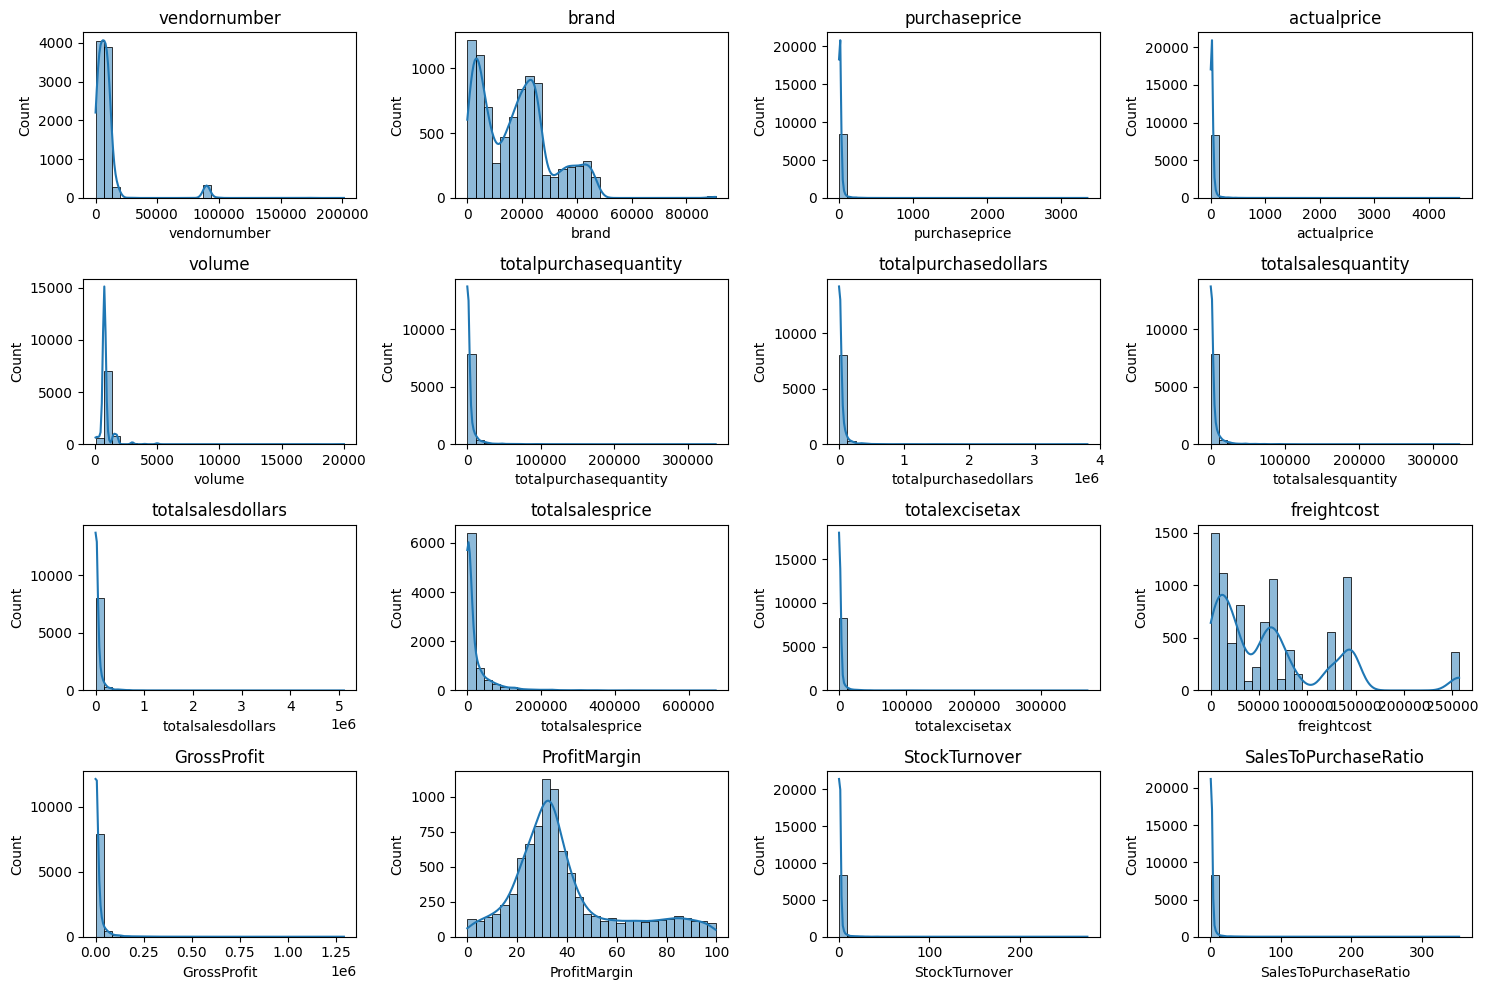

In [604]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # adjust greed layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
    
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

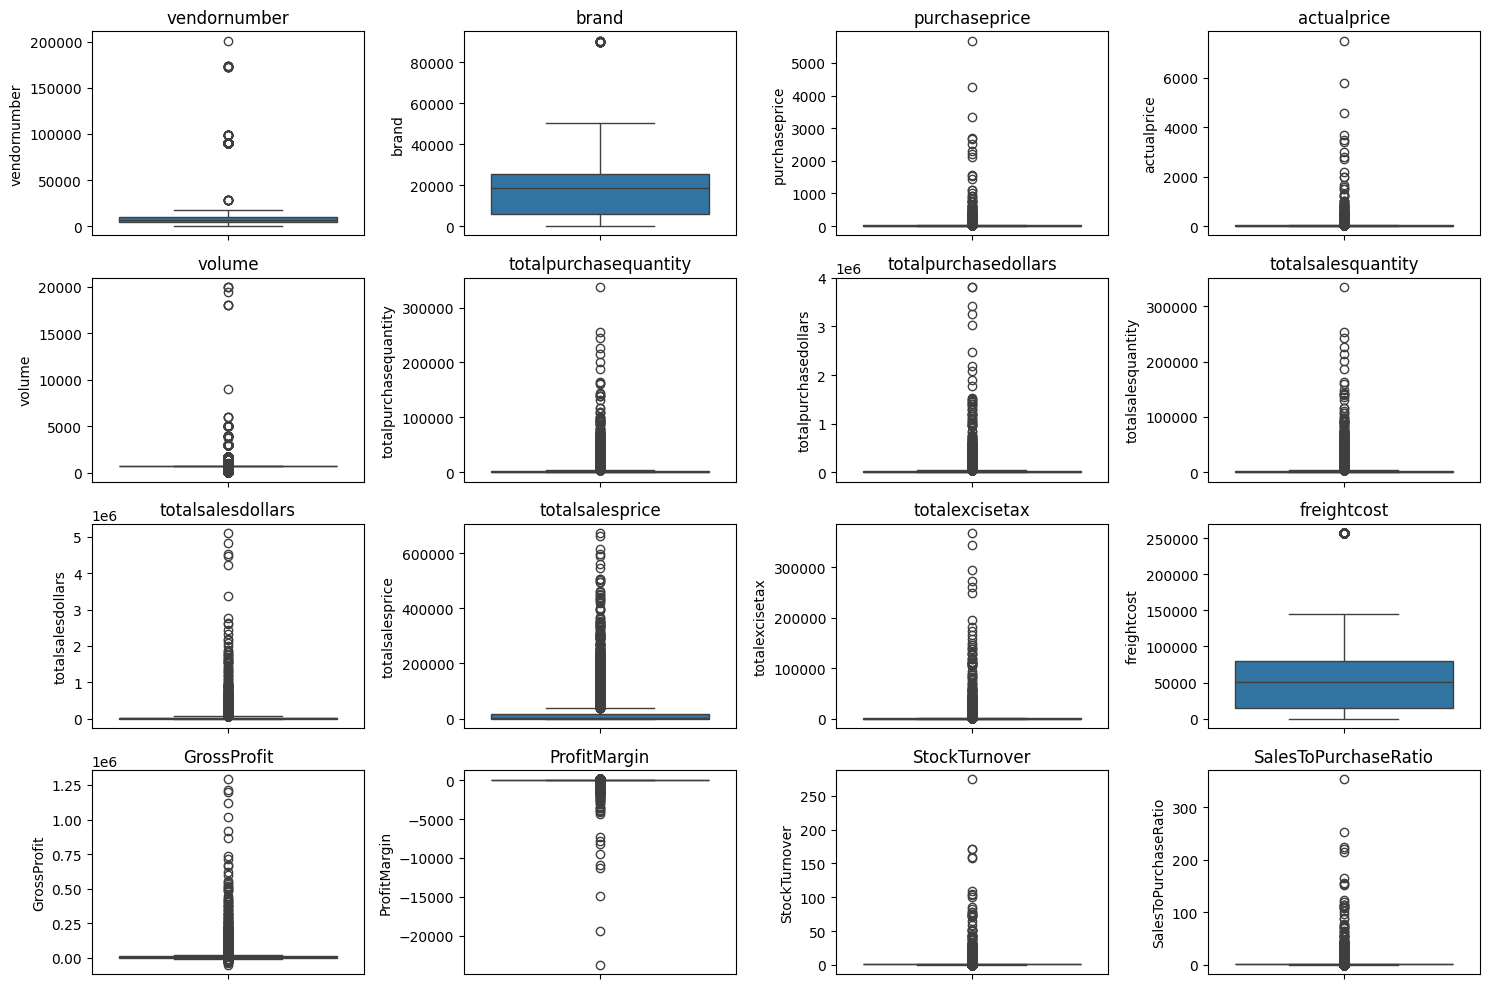

In [527]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # adjust greed layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights

## Negative & Zero Values

#### Gross Profit
Minimum value is **-52,002.78**, indicating that some products or transactions generated losses. This may occur because products were sold below their purchase cost or due to heavy discounts.

#### Profit Margin
The minimum value is **-∞ (negative infinity)**, which indicates that **Total Sales Dollars = 0** for some records, resulting in a division-by-zero scenario during Profit Margin calculation.

#### Total Sales Quantity & Total Sales Dollars
The minimum values are **0**, meaning some products were purchased but never sold. These items could represent slow-moving, obsolete, or newly stocked inventory.

---

## Outliers Indicated by High Standard Deviations

#### Purchase Price & Actual Price
The maximum values (**5,681.81** and **7,499.99**) are significantly higher than their respective means (**24.39** and **35.64**), indicating the presence of premium or luxury products within the dataset.

#### Freight Cost
Freight Cost ranges from **0.09** to **257,032.07**, showing substantial variation in shipping expenses. This may be influenced by shipment size, transportation distance, order volume, or vendor-specific logistics.

#### Stock Turnover
Stock Turnover ranges from **0** to **274.5**, indicating that some products never sold while others sold much faster than inventory was replenished. Values greater than **1** may suggest strong demand or sales from previously accumulated inventory.

---

# Interview Insights (Business Interpretation)

## 1. Negative Gross Profit

#### Insight

Some products are being sold at a loss. This could happen because of aggressive discounting or when the purchase cost exceeds the selling price.

#### Business Recommendation

- Identify loss-making products.
- Review and optimize the pricing strategy.
- Negotiate better purchase prices with vendors.

---

## 2. Negative Profit Margin

#### Insight

A Profit Margin of **-∞** indicates that **Total Sales Dollars = 0**.

#### Formula

**Profit Margin = Gross Profit / Total Sales Dollars**

When the denominator is **0**, the calculation results in infinity or undefined values.

#### Recommendation

Always handle division-by-zero before calculating Profit Margin.

#### Example

```python
np.where(
    df['totalsalesdollars'] == 0,
    0,
    (df['GrossProfit'] / df['totalsalesdollars']) * 100
)
```

---

## 3. Zero Sales

#### Insight

Products were purchased but generated no sales.

#### Possible Reasons

- Slow-moving products
- Dead stock
- Low customer demand
- Newly added inventory

#### Recommendation

- Launch promotional campaigns.
- Identify and manage overstocked inventory.
- Review product demand and inventory planning.

---

## 4. Premium Products

The maximum Purchase Price and Selling Price are significantly higher than the average values.

#### Insight

The dataset contains premium or luxury products, making the overall mean less representative of the majority of products.

#### Recommendation

Analyze premium and regular products separately for more meaningful insights.

---

## 5. Freight Cost

Freight Cost shows significant variation across transactions.

#### Insight

Some vendors or shipments incur exceptionally high logistics costs.

#### Recommendation

- Perform vendor-wise freight cost analysis.
- Identify opportunities to optimize shipping and logistics expenses.

---

## 6. Stock Turnover

- **0** → Product was never sold.
- **1** → Sales approximately equal purchases.
- **>1** → Sales exceeded current purchase volume.

#### Possible Reasons

- Sales from older inventory.
- High customer demand.
- Inventory replenishment delays or shortages.

#### Recommendation

Monitor products with extremely low or high turnover to improve inventory planning, reduce stockouts, and minimize excess inventory.

In [528]:
# let's filter the data by removing inconsistencies
df=pd.read_sql_query("""select * from 
vendor_sales_summary 
where grossprofit>0
and profitmargin>0
and totalsalesquantity>0""",conn)

In [ ]:
df.to_csv("vendor_sales_summary.csv", index=False)

In [600]:
df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE grossprofit > 0
AND profitmargin > 0
AND totalsalesquantity > 0
""", conn)

df.to_csv("vendor_sales_summary_filtered.csv", index=False)

print("CSV downloaded successfully!")

CSV downloaded successfully!


In [529]:
df

,vendornumber,vendorname,brand,description,purchaseprice,actualprice,volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,freightcost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


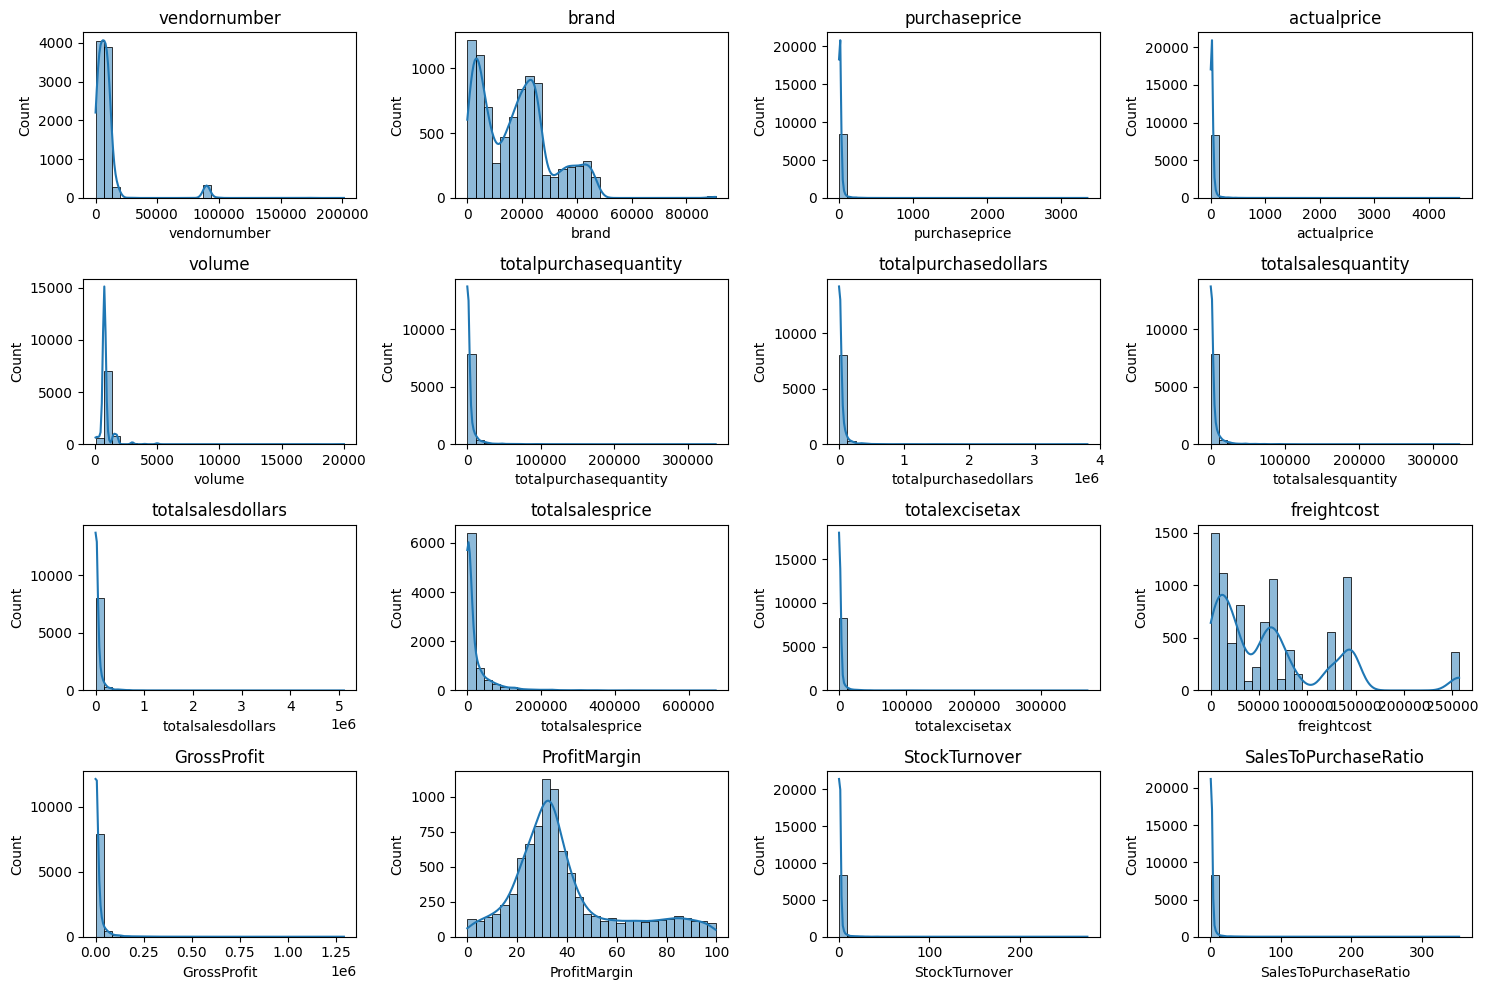

In [530]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # adjust greed layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

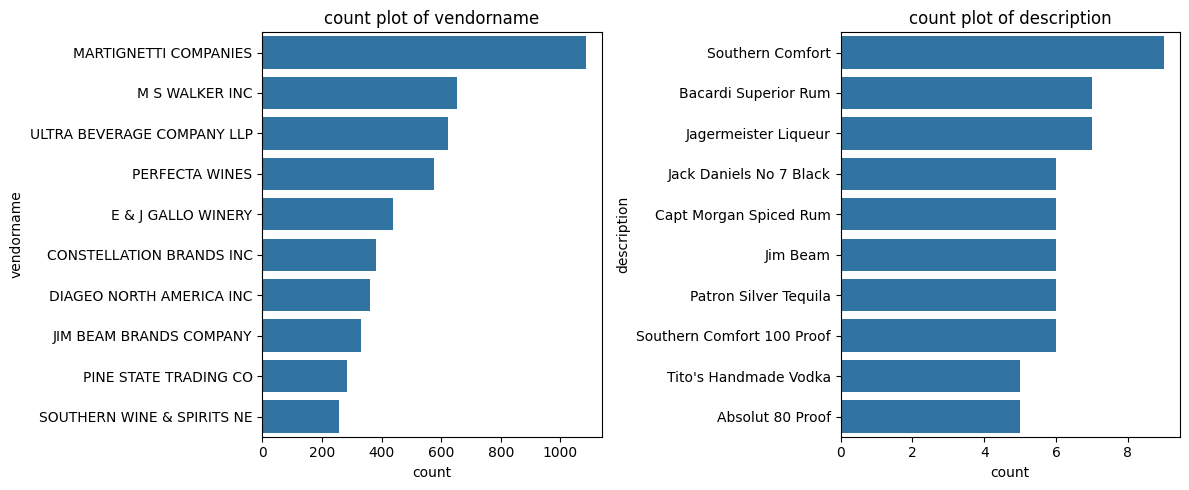

In [531]:
# count plots for categorical columns 
categorical_cols= ["vendorname","description"]

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

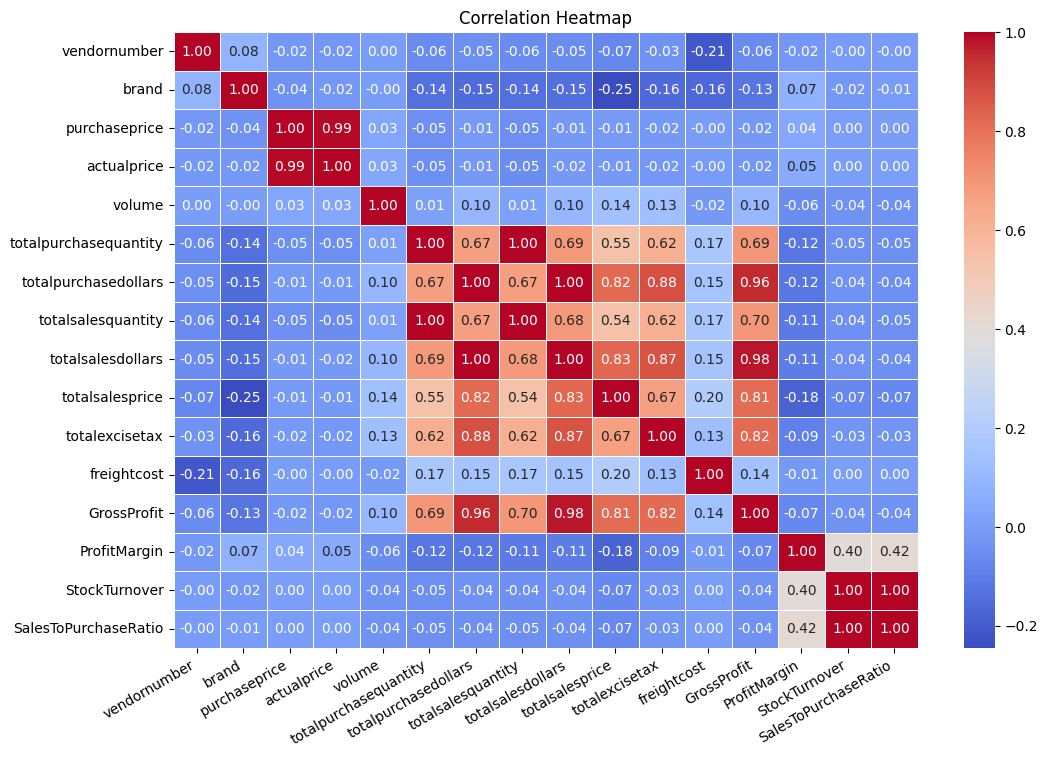

In [532]:
# Correalation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidth=0.5)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. Correlation values range from **-1 to +1**:

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

The heatmap helps identify relationships between variables, detect multicollinearity, and uncover business insights.

---

# Correlation Insights

## 1. Purchase Price vs Sales Revenue

#### Insight

Purchase Price has a **very weak negative correlation** with **Total Sales Dollars (-0.012)** and **Gross Profit (-0.016)**.

This indicates that changes in purchase price have almost no direct impact on sales revenue or gross profit.

#### Business Recommendation

- Focus more on pricing strategy and sales volume than purchase cost alone.
- Optimize vendor negotiations without expecting significant revenue changes.

---

## 2. Purchase Quantity vs Sales Quantity

#### Insight

**Total Purchase Quantity** and **Total Sales Quantity** have a **very strong positive correlation (0.999)**.

This suggests that inventory purchased is almost entirely converted into sales, indicating efficient inventory movement.

#### Business Recommendation

- Maintain optimal inventory levels.
- Use demand forecasting to avoid stock shortages and excess inventory.

---

## 3. Profit Margin vs Total Sales Price

#### Insight

Profit Margin has a **negative correlation (-0.179)** with **Total Sales Price**.

This indicates that increasing sales price does not always increase profitability. High-priced products may involve higher costs, discounts, or promotional pricing.

#### Business Recommendation

- Analyze product profitability instead of focusing only on sales value.
- Review pricing strategies for low-margin products.

---

## 4. Stock Turnover vs Profitability

#### Insight

Stock Turnover has **weak negative correlations** with:

- **Gross Profit (-0.038)**
- **Profit Margin (-0.055)**

This suggests that faster inventory movement does not necessarily result in higher profits.

#### Business Recommendation

- Evaluate products based on both turnover and profitability.
- Focus on maximizing profit rather than only increasing inventory turnover.

---

## 5. Strong Positive Correlations

#### Insight

Several sales-related variables show strong positive relationships because they are derived from similar business transactions.

Examples include:

- Purchase Quantity ↔ Sales Quantity
- Total Purchase Dollars ↔ Total Sales Dollars

#### Business Recommendation

- These variables validate data consistency.
- Highly correlated variables should be reviewed before building predictive models to avoid multicollinearity.

---

## Overall Business Conclusion

The correlation analysis shows that inventory purchasing and sales quantities are highly aligned, indicating efficient inventory management.
    However, profitability is not strongly influenced by purchase price or stock turnover alone. 
    Improving pricing strategies, optimizing vendor costs, and focusing on product-level profitability can help maximize business performance.

# Data Analysis
identify brands that needs promotional or pricing Adjustments which exhibit lower sales
performance but higher profit margins.


In [533]:
print(df.columns.tolist())

['vendornumber', 'vendorname', 'brand', 'description', 'purchaseprice', 'actualprice', 'volume', 'totalpurchasequantity', 'totalpurchasedollars', 'totalsalesquantity', 'totalsalesdollars', 'totalsalesprice', 'totalexcisetax', 'freightcost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']


In [534]:
brand_performance = df.groupby('description').agg({
'totalsalesdollars':'sum',
'ProfitMargin':'mean'}).reset_index()

In [597]:
print(brand_performance.columns)

Index(['description', 'totalsalesdollars', 'ProfitMargin'], dtype='str')


In [536]:
low_sales_threshold = brand_performance['totalsalesdollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [537]:
low_sales_threshold

np.float64(560.299)

In [538]:
high_margin_threshold

np.float64(64.97017552750113)

In [539]:
# filter brands with low sales but high profit margins
target_brands = brand_performance[
(brand_performance['totalsalesdollars']<= low_sales_threshold) &
(brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with low Sales but High Profit Margins:")
display(target_brands.sort_values('totalsalesdollars'))

Brands with low Sales but High Profit Margins:


,description,totalsalesdollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [540]:
brand_performance =brand_performance[brand_performance['totalsalesdollars']<10000]# for better visualization

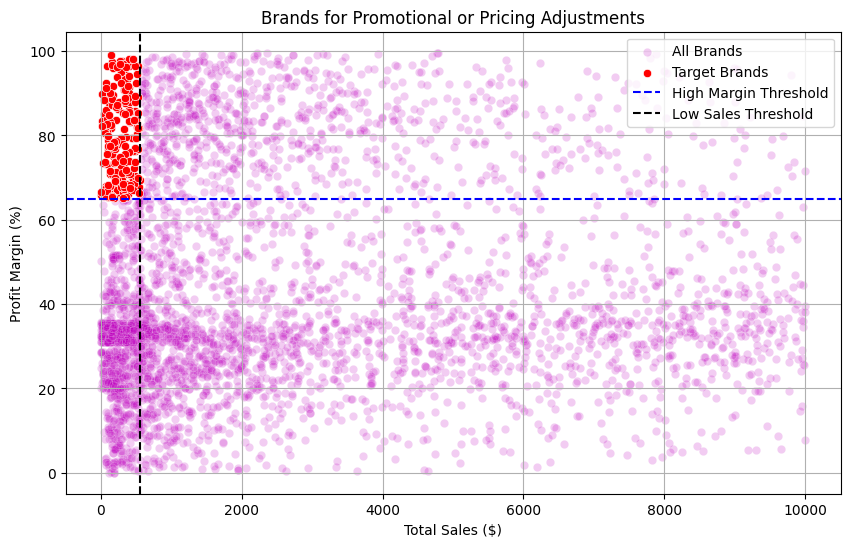

In [541]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='totalsalesdollars',
    y='ProfitMargin',
    color='m',
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='totalsalesdollars',
    y='ProfitMargin',
    color='red',
    label="Target Brands"
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='b',
    label="High Margin Threshold"_t
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='k',
    label="Low Sales Threshold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

#### Which vendors and brands demonstrate the highest sales performance?

In [542]:
top_vendors=df.groupby("vendorname")["totalsalesdollars"].sum().nlargest(10)
top_brands=df.groupby("description")["totalsalesdollars"].sum().nlargest(10)
top_vendors

vendorname
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: totalsalesdollars, dtype: float64

In [543]:
top_brands

description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: totalsalesdollars, dtype: float64

In [544]:
# the value must be redable like 1M,204K,etc
def format_dollars(value):
    if value >=1000000:
        return f"{value / 1000000:.2f}M"
    elif value>=1000:
        return f"{value / 1000:.2f}K"
    else:
        return str(value)
    


In [545]:
top_brands.apply(lambda x: format_dollars(x))

description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: totalsalesdollars, dtype: str

In [546]:
top_vendors.apply(lambda x: format_dollars(x))

vendorname
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: totalsalesdollars, dtype: str

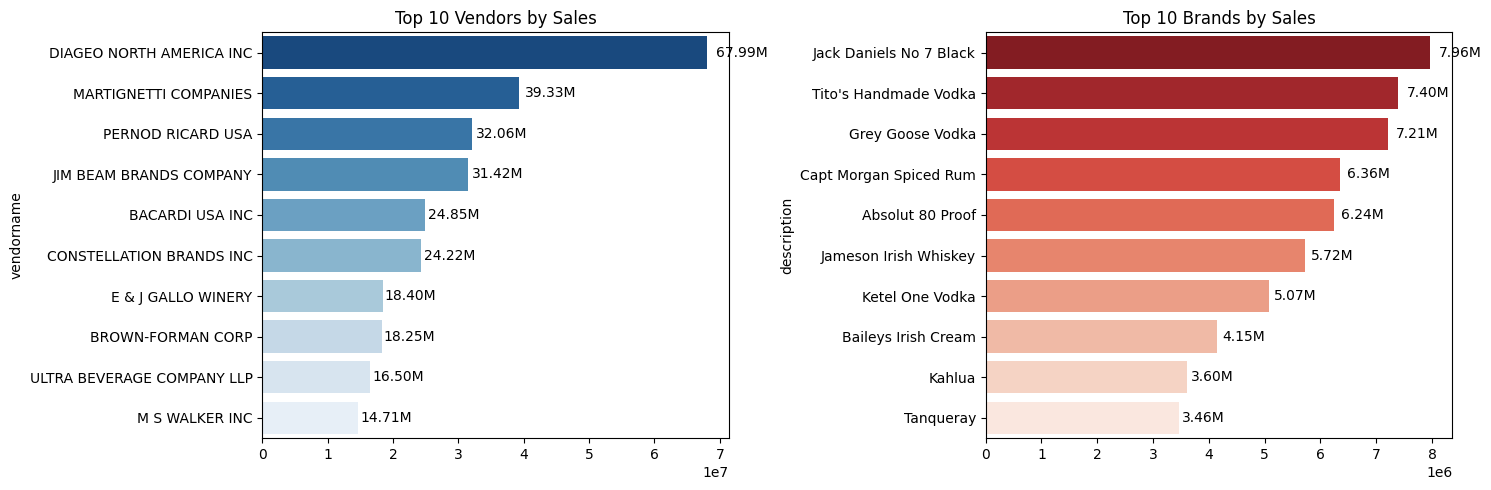

In [547]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

### Which vendors contribute the most to total purchase dollars?


In [548]:
print(df.columns)

Index(['vendornumber', 'vendorname', 'brand', 'description', 'purchaseprice',
       'actualprice', 'volume', 'totalpurchasequantity',
       'totalpurchasedollars', 'totalsalesquantity', 'totalsalesdollars',
       'totalsalesprice', 'totalexcisetax', 'freightcost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio'],
      dtype='str')


In [549]:
vendor_performance=df.groupby('vendorname').agg({
    'totalpurchasedollars':'sum',
    'GrossProfit':'sum',
    'totalsalesdollars':'sum'
}).reset_index()

In [550]:
vendor_performance

,vendorname,totalpurchasedollars,GrossProfit,totalsalesdollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [551]:
vendor_performance['purchasecontribution%']=vendor_performance['totalpurchasedollars']/vendor_performance['totalpurchasedollars'].sum()*100

In [552]:
vendor_performance

,vendorname,totalpurchasedollars,GrossProfit,totalsalesdollars,purchasecontribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000145
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.008362
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.003809
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000304
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.033981
...,...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13,0.013892
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83,0.097097
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20,1.912074
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28,1.693183


In [553]:
vendor_performance=round(vendor_performance.sort_values('purchasecontribution%',ascending=False),2)
vendor_performance

,vendorname,totalpurchasedollars,GrossProfit,totalsalesdollars,purchasecontribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [554]:
print(vendor_performance.columns)

Index(['vendorname', 'totalpurchasedollars', 'GrossProfit',
       'totalsalesdollars', 'purchasecontribution%'],
      dtype='str')


In [555]:
# Display Top 10 Vendors
top_vendors=vendor_performance.head(10)
top_vendors['totalsalesdollars']=top_vendors['totalsalesdollars'].apply(format_dollars)
top_vendors['totalpurchasedollars']=top_vendors['totalpurchasedollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,vendorname,totalpurchasedollars,GrossProfit,totalsalesdollars,purchasecontribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [556]:
vendor_performance.shape

(119, 5)

In [557]:
top_vendors['purchasecontribution%'].sum()

np.float64(65.69000000000001)

In [558]:
top_vendors['cumulative_contribution%']=top_vendors['purchasecontribution%'].cumsum()
top_vendors

,vendorname,totalpurchasedollars,GrossProfit,totalsalesdollars,purchasecontribution%,cumulative_contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


In [559]:
print(type(top_vendors))
print(type(vendor_performance))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [560]:
# top_vendors = (
#     vendor_performance
#     .sort_values(by='purchasecontribution%', ascending=False)
#     .head(10)
# )

In [561]:
#top_vendors = vendor_performance['purchasecontribution%'].head(10)

In [562]:
print(top_vendors.columns.tolist())

['vendorname', 'totalpurchasedollars', 'GrossProfit', 'totalsalesdollars', 'purchasecontribution%', 'cumulative_contribution%']


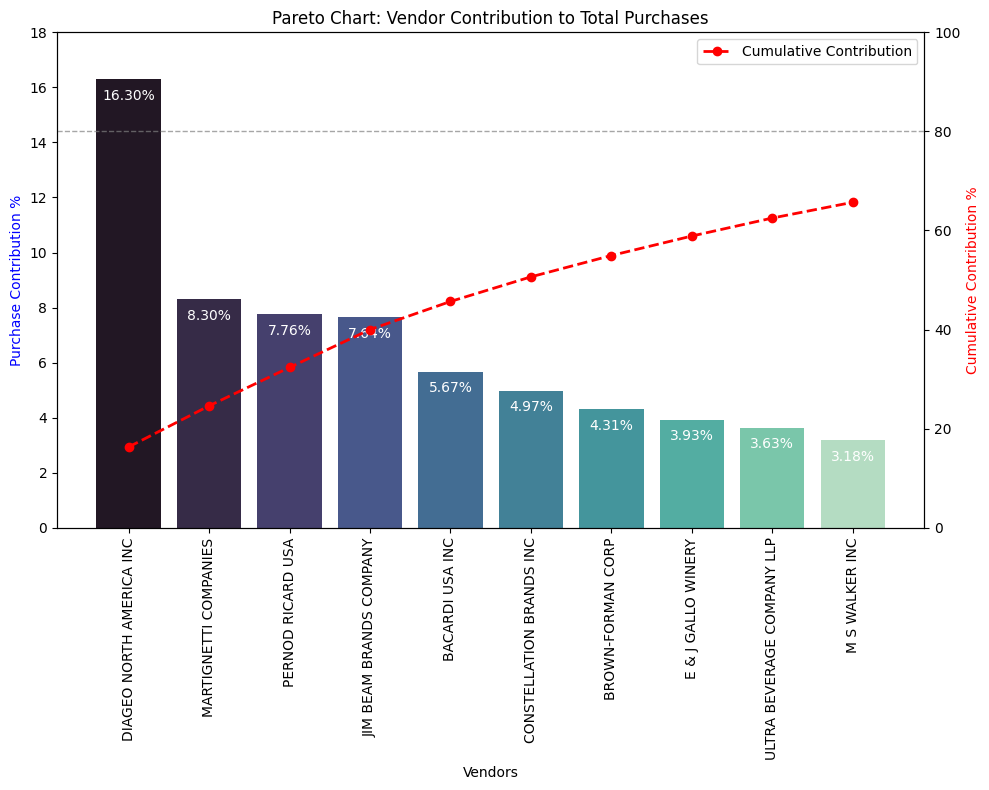

In [563]:
fig, ax1 = plt.subplots(figsize=(10,8))

# Bar Plot for Purchase Contribution %
sns.barplot(
    data=top_vendors,
    x='vendorname',
    y='purchasecontribution%',
    palette='mako',
    ax=ax1
)

# Add Percentage Labels
for i, value in enumerate(top_vendors['purchasecontribution%']):
    ax1.text(
        i,
        value - 0.6,
        f"{value:.2f}%",
        ha='center',
        va='center',
        fontsize=10,
        color='white'
    )

# Left Axis
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax1.set_xlabel('Vendors')
ax1.set_ylim(0, 18)

# Rotate Vendor Names
ax1.tick_params(axis='x', rotation=90)

# Right Axis
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['vendorname'],
    top_vendors['cumulative_contribution%'],
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    markersize=6,
    label='Cumulative Contribution'
)

ax2.set_ylabel('Cumulative Contribution %', color='red')
ax2.set_ylim(0, 100)

# 80% Reference Line
ax2.axhline(
    y=80,
    color='gray',
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

ax2.legend(loc='upper right')

plt.title('Pareto Chart: Vendor Contribution to Total Purchases')

plt.tight_layout()
plt.show()

### How much of total procurement is dependent on the top vendors?

In [564]:
print(top_vendors.columns)

Index(['vendorname', 'totalpurchasedollars', 'GrossProfit',
       'totalsalesdollars', 'purchasecontribution%',
       'cumulative_contribution%'],
      dtype='str')


In [565]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['purchasecontribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 65.69%


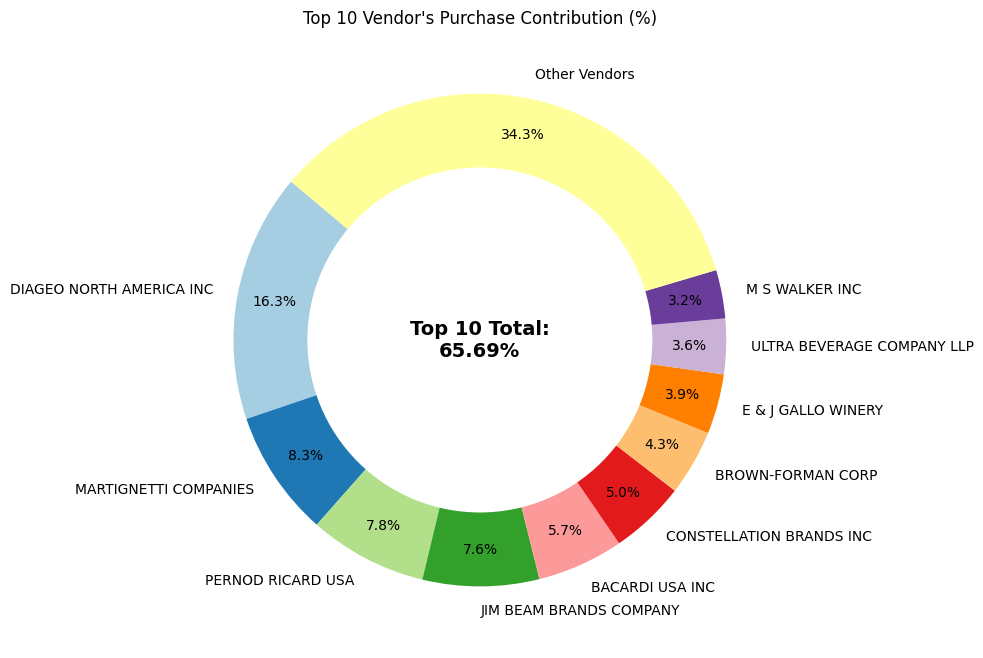

In [566]:
vendors = list(top_vendors['vendorname'].values)
purchase_contributions = list(top_vendors['purchasecontribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [567]:
df['unitpurchaseprice']=df['totalpurchasedollars']/df['totalpurchasequantity']

In [568]:
df["ordersize"]=pd.qcut(df["totalpurchasequantity"],q=3,labels=["Small","Medium","Large"])

In [569]:
df[['ordersize','totalpurchasequantity']]

,ordersize,totalpurchasequantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [570]:
df.groupby('ordersize')[['unitpurchaseprice']].mean()

,unitpurchaseprice
ordersize,
Small,39.068186
Medium,15.486414
Large,10.777625


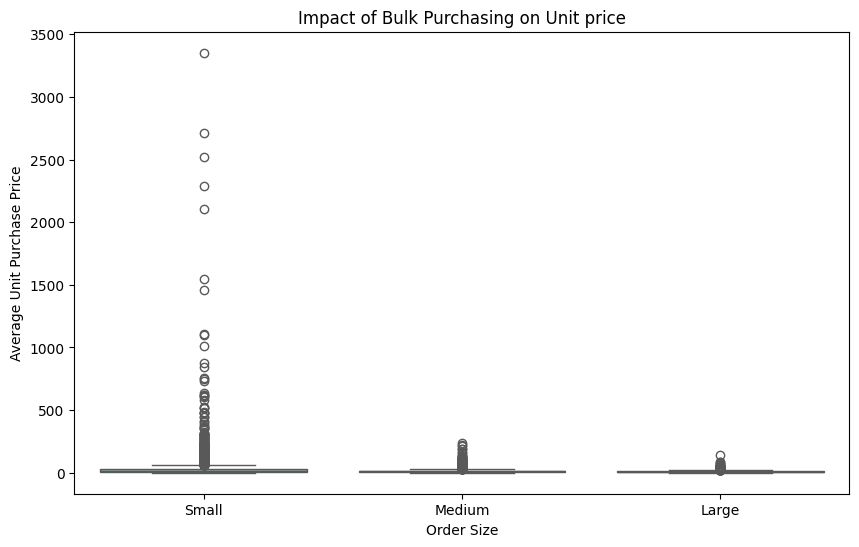

In [571]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="ordersize",y="unitpurchaseprice",palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

# Order Size vs Average Unit Price Analysis

## Business Objective

This analysis compares the **Average Unit Price** across different order sizes (**Small, Medium, and Large**) to understand the impact of bulk purchasing on pricing.

The box plot highlights the distribution of unit prices, median values, variability, and potential outliers for each order size category.

---

# Key Insights

## 1. Large Orders Have the Lowest Average Unit Price

#### Insight

Large orders have the lowest average unit price compared to Small and Medium orders.

This indicates that vendors purchasing in bulk receive better pricing and volume discounts.

#### Business Recommendation

- Encourage customers to place larger orders by offering attractive bulk discount programs.
- Strengthen bulk purchasing incentives to increase sales volume.

---

## 2. Small Orders Have the Highest Price Variation

#### Insight

Small orders show a wide spread with many high-value outliers, indicating significant variation in unit prices.

This may be due to premium products, specialty items, or low-volume purchases.

#### Business Recommendation

- Review pricing consistency for small orders.
- Identify premium products separately to improve pricing analysis.

---

## 3. Medium Orders Follow the Same Trend

#### Insight

Medium-sized orders have lower average prices than Small orders but remain higher than Large orders.

This suggests a gradual reduction in unit price as order quantity increases.

#### Business Recommendation

- Offer incentives to convert medium-order customers into large-order buyers.
- Introduce quantity-based discount tiers.

---

## 4. Presence of Outliers

#### Insight

All three order-size categories contain outliers, with the highest concentration in Small orders.

These outliers may represent premium products, exceptional transactions, or data anomalies.

#### Business Recommendation

- Investigate unusually high-priced transactions.
- Validate whether they represent genuine business cases or data quality issues.

---

# Overall Business Conclusion

The analysis confirms that **bulk purchasing reduces the average unit price**, making large orders more cost-efficient. 
The pricing strategy appears to successfully encourage higher purchase volumes while maintaining competitive pricing. However, 
The large number of outliers in Small orders should be reviewed to ensure pricing consistency and identify premium product segments.

#### Which vendors have low inventory turnover,indicating excess stock and slow-moving products ?

In [572]:
print(df.columns)

Index(['vendornumber', 'vendorname', 'brand', 'description', 'purchaseprice',
       'actualprice', 'volume', 'totalpurchasequantity',
       'totalpurchasedollars', 'totalsalesquantity', 'totalsalesdollars',
       'totalsalesprice', 'totalexcisetax', 'freightcost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio',
       'unitpurchaseprice', 'ordersize'],
      dtype='str')


In [573]:
df[df['StockTurnover']<1].groupby('vendorname')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
vendorname,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#### How much capital is locked in unsold inventory per vendor,and which vendors contribute th most to it?

In [574]:
df["unsoldinventoryvalue"]=(df["totalpurchasequantity"]-df["totalsalesquantity"]) * df["purchaseprice"]
print('Total Unsold Capital:',format_dollars(df["unsoldinventoryvalue"].sum()))

Total Unsold Capital: 2.71M


In [575]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("vendorname")["unsoldinventoryvalue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="unsoldinventoryvalue",ascending=False)
inventory_value_per_vendor['unsoldinventoryvalue']=inventory_value_per_vendor['unsoldinventoryvalue'].apply(format_dollars)
inventory_value_per_vendor.head(10) 

,vendorname,unsoldinventoryvalue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [576]:
top_threshold=df["totalsalesdollars"].quantile(0.75)
low_threshold=df["totalsalesdollars"].quantile(0.25)

In [577]:
top_vendors=df[df["totalsalesdollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["totalsalesdollars"]<= low_threshold]["ProfitMargin"].dropna()

In [578]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


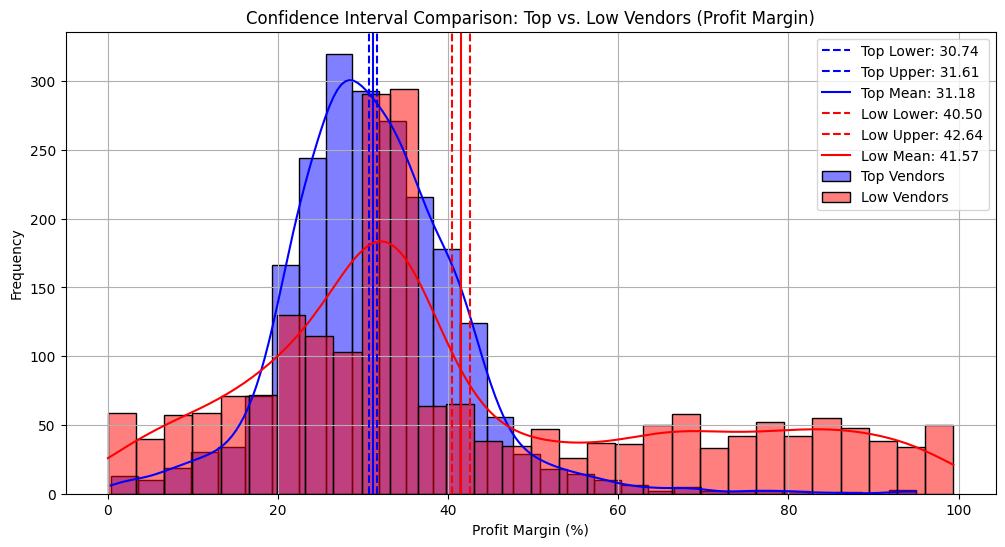

In [579]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data)-1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val-margin_of_error, mean_val+margin_of_error

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

# Top Vendors
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Confidence Interval Analysis

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

---

# Additional Business Insights

## 1. Top Vendors Follow a High-Volume Strategy

#### Insight

Top-performing vendors generate higher sales while operating with relatively lower profit margins, indicating a volume-driven business strategy.

#### Business Recommendation

Continue focusing on high sales volume while improving operational efficiency to increase overall profitability.

---

## 2. Low Vendors Have Pricing Power

#### Insight

Low-performing vendors achieve higher profit margins but contribute less to total sales, suggesting premium pricing or niche product offerings.

#### Business Recommendation

Increase marketing efforts and improve product visibility to boost sales without significantly reducing margins.

---

## 3. Confidence Intervals Show Statistical Significance

#### Insight

The confidence intervals of the two vendor groups do not overlap, indicating that the difference in average profit margins is statistically significant rather than due to random variation.

#### Business Recommendation

Use separate pricing and sales strategies for Top Vendors and Low Vendors instead of applying a common approach across all vendors.

---

## Overall Business Conclusion

The analysis indicates that **Top Vendors focus on higher sales with lower margins**, whereas **Low Vendors focus on higher margins with lower sales volume**. A balanced strategy combining efficient pricing, cost optimization, and increased sales volume can maximize overall business profitability.

## Is there a significant difference in profit margins between top-performing and low-performing vendors ?

# Hypothesis Testing (Independent Two-Sample T-Test)

## Business Objective

The objective of this analysis is to determine whether there is a statistically significant difference in **Profit Margin (%)** between **Top-Performing Vendors** and **Low-Performing Vendors**.

---

# Hypotheses

### Null Hypothesis (H₀)

There is **no significant difference** in the average profit margins of Top Vendors and Low Vendors.

### Alternative Hypothesis (H₁)

There **is a significant difference** in the average profit margins of Top Vendors and Low Vendors.

---

## Statistical Method

An **Independent Two-Sample T-Test (Welch's T-Test)** is used because the two vendor groups are independent and may have different variances.

### Decision Rule

- If **P-value < 0.05**, Reject the Null Hypothesis.
- If **P-value ≥ 0.05**, Fail to Reject the Null Hypothesis.

In [595]:
from scipy.stats import ttest_ind

top_threshold = df['totalsalesdollars'].quantile(0.75)
low_threshold = df['totalsalesdollars'].quantile(0.25)

top_vendors = df[df['totalsalesdollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['totalsalesdollars'] <= low_threshold]['ProfitMargin'].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print Results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between Top and Low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between Top and Low-performing vendors.


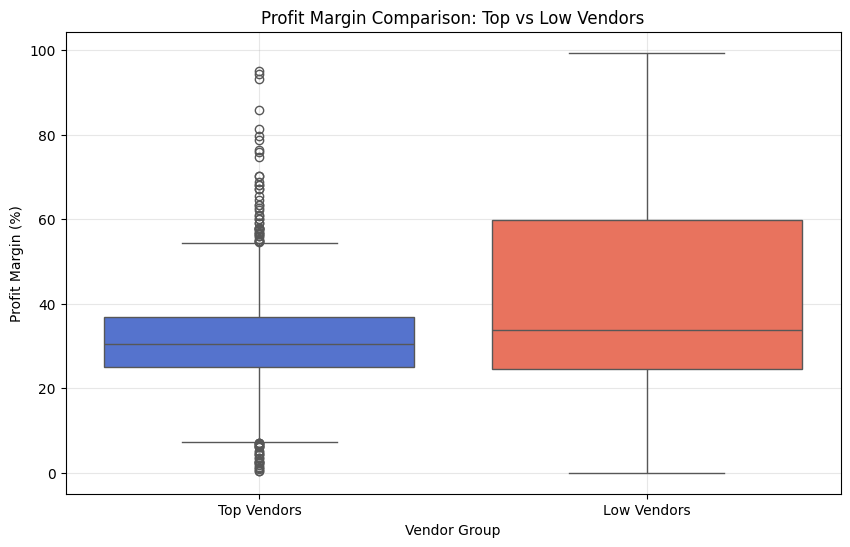

In [593]:
comparison_df = pd.concat([
    df[df['totalsalesdollars'] >= top_threshold].assign(Group='Top Vendors'),
    df[df['totalsalesdollars'] <= low_threshold].assign(Group='Low Vendors')
])

plt.figure(figsize=(10,6))
sns.boxplot(data=comparison_df, x='Group', y='ProfitMargin', palette=['royalblue','tomato'])
plt.title("Profit Margin Comparison: Top vs Low Vendors")
plt.xlabel("Vendor Group")
plt.ylabel("Profit Margin (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Hypothesis Testing Insights

## 1. Significant Difference in Profit Margins

#### Insight

The T-Test produced a **P-value less than 0.05**, indicating a statistically significant difference between the average profit margins of Top Vendors and Low Vendors.

#### Business Recommendation

Different pricing and procurement strategies should be adopted for Top Vendors and Low Vendors instead of using a single business strategy.

---

## 2. Top Vendors Operate on Higher Sales Volume

#### Insight

Top Vendors generate larger sales volumes while maintaining relatively lower profit margins.

#### Business Recommendation

Focus on improving operational efficiency and reducing procurement costs instead of increasing selling prices.

---

## 3. Low Vendors Maintain Higher Margins

#### Insight

Low Vendors achieve higher average profit margins but contribute less to overall sales revenue.

#### Business Recommendation

Increase product visibility, marketing efforts, and distribution channels to improve sales while preserving healthy profit margins.

---

## 4. Statistical Confidence

#### Insight

Since the Null Hypothesis is rejected, the observed difference in profit margins is statistically significant and is unlikely to have occurred by chance.

#### Business Recommendation

Business decisions regarding pricing, promotions, and vendor management should be based on these statistically validated results.

---

# Overall Business Conclusion

The hypothesis test confirms that **Top Vendors and Low Vendors follow different profitability strategies**. Top Vendors prioritize sales volume with relatively lower margins, while Low Vendors generate higher margins with lower sales volumes. Segment-specific pricing and procurement strategies can help maximize overall business profitability.